# Test spectrum of a system

[0.09729378 0.87564401]


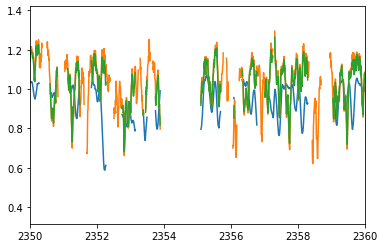

In [1]:
# make test spectrum of system: 50% ROXs12A + 50% 2M0355

import numpy as np
import matplotlib.pyplot as plt

def load_spec_file(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    flerr=file[:,2]
    return wl,fl,flerr

wlA,flA,flerrA=load_spec_file('/home/natalie/Desktop/atm_retrieval/ROXs12A/ROXs12A_spectrum.txt')
wlB,flB,flerrB=load_spec_file('/home/natalie/Desktop/atm_retrieval/2M0355/2M0355_spectrum.txt')

# interpolate wl of B onto A
flB_interp = np.interp(wlA, wlB, flB)
errB_interp = np.interp(wlA, wlB, flerrB)

# add A+B
ratioA = 0.1 # for testing other scenarios
ratioB = 1-ratioA
flux = ratioA*flA+ratioB*flB
err = np.sqrt(flerrA**2+errB_interp**2)
plt.plot(wlA,flA)
plt.plot(wlB,flB)
plt.plot(wlA,flux)
plt.xlim(2350,2360)
flux/=np.nanmedian(flux) # normalize again

spectrum=np.full(shape=(3*7*2048,3),fill_value=np.nan)
spectrum[:,0]=wlA
spectrum[:,1]=flux
spectrum[:,2]=err.flatten()
#np.savetxt('./testsys/testsys_spectrum.txt',spectrum,delimiter=' ',header='wavelength (nm) flux flux_error')

# test if correct fit can be retrieved
from scipy.optimize import nnls

# ignore nans for least squares
nonans = np.isfinite(flux) & np.isfinite(flA) & np.isfinite(flB_interp) & np.isfinite(flerrA) & np.isfinite(errB_interp)
M = np.vstack([flA[nonans], flB[nonans]]).T # create model matrix, shape (2, N)
d = flux[nonans] # data
inv_cov = np.diag(1/err[nonans]**2) # define inverse of covariance matrix

# set up equation to solve (see Ruffio+2019 Appendix A)
lhs = M.T @ inv_cov @ M # left-hand side
rhs = M.T @ inv_cov @ d # right-hand side
phi, _ = nnls(lhs, rhs)
print(phi)

In [ ]:
# make test spectrum of system: 50% ROXs12A + 50% testspec

import numpy as np
import matplotlib.pyplot as plt

def load_spec_file(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    flerr=file[:,2]
    return wl,fl,flerr

wlA,flA,flerrA=load_spec_file('/home/natalie/Desktop/atm_retrieval/ROXs12A/ROXs12A_spectrum.txt')
wlB,flB,flerrB=load_spec_file('/home/natalie/Desktop/atm_retrieval/2M0355/2M0355_spectrum.txt')

# interpolate wl of B onto A
flB_interp = np.interp(wlA, wlB, flB)
errB_interp = np.interp(wlA, wlB, flerrB)

# add A+B
ratioA = 0.1 # for testing other scenarios
ratioB = 1-ratioA
flux = ratioA*flA+ratioB*flB
err = np.sqrt(flerrA**2+errB_interp**2)
plt.plot(wlA,flA)
plt.plot(wlB,flB)
plt.plot(wlA,flux)
plt.xlim(2350,2360)
flux/=np.nanmedian(flux) # normalize again

spectrum=np.full(shape=(3*7*2048,3),fill_value=np.nan)
spectrum[:,0]=wlA
spectrum[:,1]=flux
spectrum[:,2]=err.flatten()
#np.savetxt('./testsys/testsys_spectrum.txt',spectrum,delimiter=' ',header='wavelength (nm) flux flux_error')

# test if correct fit can be retrieved
from scipy.optimize import nnls

# ignore nans for least squares
nonans = np.isfinite(flux) & np.isfinite(flA) & np.isfinite(flB_interp) & np.isfinite(flerrA) & np.isfinite(errB_interp)
M = np.vstack([flA[nonans], flB[nonans]]).T # create model matrix, shape (2, N)
d = flux[nonans] # data
inv_cov = np.diag(1/err[nonans]**2) # define inverse of covariance matrix

# set up equation to solve (see Ruffio+2019 Appendix A)
lhs = M.T @ inv_cov @ M # left-hand side
rhs = M.T @ inv_cov @ d # right-hand side
phi, _ = nnls(lhs, rhs)
print(phi)

# Other

In [1]:
# spectral resolution

from target import Target
bd = Target('ROXs12A')
wl,fl,err = bd.load_spectrum()
res = bd.calc_resolution()
print(res) # mean
print(bd.spec_resolution) # all order/dets

63088.33998377872
[[59715.61116754 62974.89338345 66760.03257009]
 [59744.87789753 63036.87023503 66853.63374988]
 [59799.19780577 63061.49268731 66855.46321002]
 [59849.43383351 63088.33998378 66869.18642593]
 [59890.6650157  63139.14285322 66908.99453152]
 [59932.13264088 63190.48324078 66959.06158776]
 [59974.65773933 63273.27416509 67044.81768477]]


# CMD

<ipython-input-2-ab065dca7cff>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
<ipython-input-2-ab065dca7cff>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
<ipython-input-2-ab065dca7cff>:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_K[np.isnan(all_K)] = data[np.isnan(all_K)]['Ks_2MASS']
<ipython-input-2-ab06

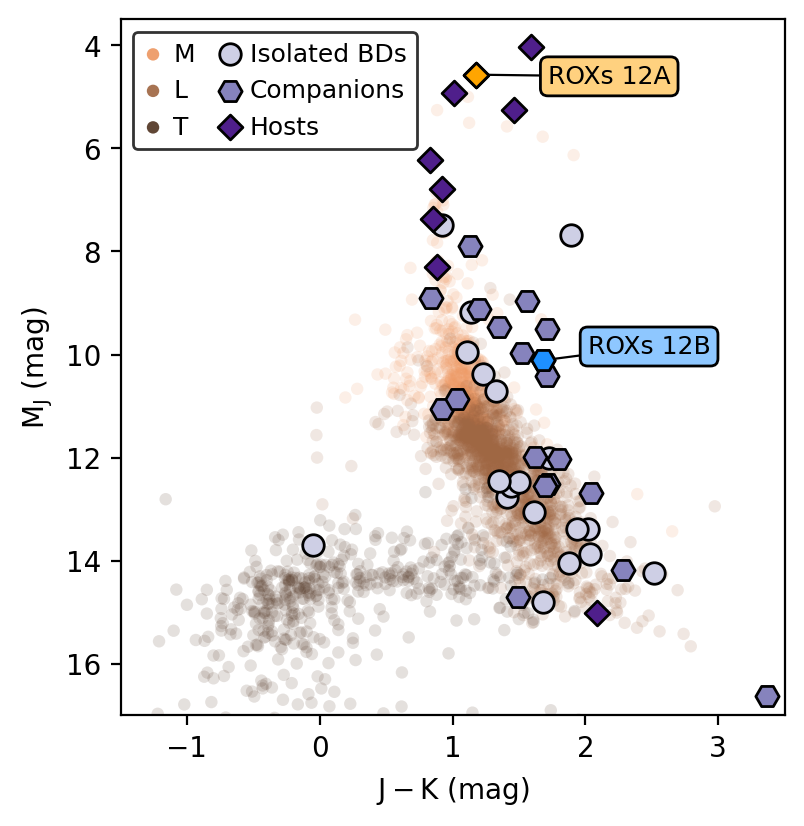

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors
import os
os.environ['pRT_input_data_path'] = "/home/natalie/.local/lib/python3.8/site-packages/petitRADTRANS/input_data_std/input_data"
from target import Target

# Load the Ultracool dwarfs sample
Ultracool_data = pd.read_csv('./UltracoolSheet_Main.csv')

SupJup_data = [
    # Name, alternative name, J_MKO, J_2MASS, K_MKO, Ks_2MASS, dist_formula, has_higher_mass_companion, separation, mass
    ['HD 1160B',                     'HD 1160B',       15.83,  np.nan, 14.12,  np.nan, 120.9, 'HD 1160A',      80,     np.nan], 
    ['HD 1160C',                     'HD 1160C',       13.31,  np.nan, 12.18,  np.nan, 120.9, 'HD 1160A',      530,    np.nan], 
    ['2MASS J02192210-3925225A',     '2M 0219A',       11.32,  np.nan, 10.44,  np.nan, 40.2,  '>2M 0219B',     -156,   np.nan], 
    ['2MASS J02192210-3925225B',     '2M 0219B',       15.54,  np.nan, 13.82,  np.nan, 40.2,  '2M 0219A',      156,    np.nan], 
    ['AB Pic b',                     'AB Pic b',       16.18,  np.nan, 14.14,  np.nan, 50.14, 'AB Pic',        273,    np.nan], 
   #['PZ Tel A',                     'PZ Tel A',       6.86,   np.nan, 6.38,   np.nan, 47.13, '>PZ Tel B',     -25,    np.nan], 
    ['PZ Tel B',                     'PZ Tel B',       12.26,  np.nan, 11.42,  np.nan, 47.13, 'PZ Tel A',      25,     np.nan], 
    ['2MASS J01225093-2439505A',     '2M 0122A',       10.02,  np.nan, 9.17,   np.nan, 33.74, '>2M 0122B',     -52,    np.nan], 
    ['2MASS J01225093-2439505B',     '2M 0122B',       16.81,  np.nan, 14.53,  np.nan, 33.74, '2M 0122A',      52,     np.nan], 
    ['2MASS J03552337+1133437',      '2M 0355',        np.nan, 14.05,  np.nan, 11.53,  9.16,  'N',             np.nan, np.nan], 
    ['LSPM J0036+1821',              'LSPM J0036',     np.nan, 12.47,  np.nan, 11.06,  8.74,  'N',             np.nan, np.nan], 
    ['2MASS J01033563-5515561(AB)',  '2M 0103(AB)',    10.16,  np.nan, 9.24,   np.nan, 47.21, '>2M 0103(AB)b', -84,    np.nan], 
    ['2MASS J01033563-5515561(AB)b', '2M 0103(AB)b',   15.4,   np.nan, 13.6,   np.nan, 47.21, '2M 0103(AB)',   84,     np.nan], 
    ['DENIS J025503.3-470049',       'DENIS J0255',    np.nan, 13.24,  np.nan, 11.56,  4.868, 'N',             np.nan, np.nan], 
    ['CD-35 2722A',                  'CD-35 2722A',    np.nan, 7.86,   np.nan, 7.03,   21.3,  '>CD-35 2722B',  -67,    np.nan], 
    ['CD-35 2722B',                  'CD-35 2722B',    13.63,  np.nan, 12.01,  np.nan, 21.3,  'CD-35 2722A',   67,     np.nan], 
    ['DH Tau A',                     'DH Tau A',       9.77,   np.nan, 8.18,   np.nan, 140,   '>DH Tau B',     -328.2, np.nan], 
    ['DH Tau B',                     'DH Tau B',       15.71,  np.nan, 14.19,  np.nan, 140,   'DH Tau A',      328.2,  np.nan], 
    ['Luhman 16A',                   'Luhman 16A',     11.53,  np.nan, 9.44,   np.nan, 2.02,  '>Luhman 16B',   -3.12,  np.nan], 
    ['Luhman 16B',                   'Luhman 16B',     11.22,  np.nan, 9.73,   np.nan, 2.02,  'Luhman 16A',    3.12,   np.nan], 
    ['FU Tau A',                     'FU Tau A',       10.78,  np.nan, 9.32,   np.nan, 127.6, '>FU Tau B',     -800,   np.nan], 
    ['FU Tau B',                     'FU Tau B',       15.04,  np.nan, 13.33,  np.nan, 127.6, 'FU Tau A',      800,    np.nan], 
    ['HR 3549',                      'HR 3549B',       15.94,  np.nan, 15.02,  np.nan, 94.8,  'HR 3549',       80,     np.nan], # Uses H-band magnitude for K-band
   #['HR 3549',                      'HR 3549B',       15.94,  np.nan, 14.7,   np.nan, 94.8,  'HR 3549',       80,     np.nan], # Extrapolated J and H-band magnitudes
    ['2MASS J08354256-0819237',      '2M 0835',        np.nan, 13.17,  np.nan, 11.136, 7.23,  'N',             np.nan, np.nan], 
    ['beta Pic b',                   r'$\beta$ Pic b', 14.00,  np.nan, 12.30,  np.nan, 19.44, 'beta Pic A',    10.6,   np.nan], 
    ['2MASS J01415823-4633574',      '2M 0141',        np.nan, 14.83,  np.nan, 13.10,  36.65, 'N',             np.nan, np.nan], 
    ['2MASS J05233822-1403022',      '2M 0523',        np.nan, 13.08,  np.nan, 11.638, 12.73, 'N',             np.nan, np.nan], 
    ['SSSPM J0829-1309',             '2M 0829',        np.nan, 12.80,  np.nan, 11.30,  11.68, 'N',             np.nan, np.nan], 
    ['2MASS J04341527+2250309',      '2M 0434',        np.nan, 13.74,  np.nan, 11.85,  163,   'N',             np.nan, np.nan], 
    ['2MASS J05012406-0010452',      '2M 0501',        np.nan, 14.98,  np.nan, 12.96,  20.9,  'N',             np.nan, np.nan], 
    ['2MASS J05591914-1404488',      '2M 0559',        np.nan, 13.80,  np.nan, 13.85,  10.50, 'N',             np.nan, np.nan], 
    ['2MASS J11553952-3727350',      '2M 1155',        np.nan, 12.81,  np.nan, 11.46,  11.80, 'N',             np.nan, np.nan], 
    ['2MASS J14252798-3650229',      '2M 1425',        np.nan, 13.75,  np.nan, 11.81,  11.85, 'N',             np.nan, np.nan], 
    ['DENIS J060852.8-275358',       '2M 0608',        np.nan, 13.60,  np.nan, 12.37,  44.2,  'N',             np.nan, np.nan], 
    ['CD-33 7795A',                  'TWA 5A',         8.40,   np.nan, 7.39,   np.nan, 49.6,  '>TWA 5B',       -86,    np.nan], 
    ['CD-33 7795B',                  'TWA 5B',         12.6,   np.nan, 11.4,   np.nan, 49.6,  'TWA 5A',        86,     np.nan], 
    ['HIP 64892B',                   'HIP 64892B',     14.85,  np.nan, 13.50,  np.nan, 119.6, 'HIP 64892A',    159,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        16.27,  np.nan, 14.70,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        15.73,  np.nan, 14.44,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
    ['YSES 1b',                      'YSES 1b',        15.73,  np.nan, 14.70,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        14.16,  np.nan, 14.31,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], # J, Ks mag from (K1,K2)+species
   #['YSES 1c',                      'YSES 1c',        21.17,  np.nan, 17.85,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], 
   #['YSES 1c',                      'YSES 1c',        21.17,  np.nan, 18.34,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], 
    ['YSES 1c',                      'YSES 1c',        21.50,  np.nan, 18.13,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], # J, Ks mag from (K1,K2)+species
    ['2MASS J05002100+0330501',      '2M 0500',        np.nan, 13.67,  np.nan, 12.06,  13.23, 'N',             np.nan, np.nan], 
    ['2MASS J06244595-4521548',      '2M 0624',        np.nan, 14.48,  np.nan, 12.60,  12.19, 'N',             np.nan, np.nan], 
   #['GQ Lup A',                     'GQ Lup A',       8.69,   np.nan, 7.10,   np.nan, 154.1, '>GQ Lup B',     -105,   np.nan], 
    ['GQ Lup B',                     'GQ Lup B',       14.90,  np.nan, 13.34,  np.nan, 154.1, 'GQ Lup A',      105,    np.nan], 
    ['ROXs 12A',                     'ROXs 12A',       10.28,  np.nan, 9.10,   np.nan, 138.6, '>ROXs 12B',     -210,   np.nan], 
    ['ROXs 12B',                     'ROXs 12B',       15.82,  np.nan, 14.14,  np.nan, 138.6, 'ROXs 12A',      210,    np.nan], 
    ['TWA 28',                       'TWA 28',         np.nan, 13.03,  np.nan, 11.89,  59.2,  'N',             np.nan, np.nan], 
    ['2MASS J08561384-1342242',      '2M 0856',        np.nan, 13.60,  np.nan, 12.49,  53.8,  'N',             np.nan, np.nan], 
    ['2MASSI J0953212-101420',       '2M 0953',        np.nan, 13.47,  np.nan, 12.14,  35.7,  'N',             np.nan, np.nan], 
    ['2MASS J12003792-7845082',      '2M 1200',        np.nan, 12.52,  np.nan, 11.60,  101.6, 'N',             np.nan, np.nan], 
]

SupJup_data = pd.DataFrame(
    SupJup_data, 
    columns=[
        'name', 'alt_name', 
        'J_MKO', 'J_2MASS', 'K_MKO', 'Ks_2MASS', 
        'dist_formula', 'has_higher_mass_companion', 
        'separation', 'mass'
        ]
    )

# Add to the DataFrame
data = pd.concat([Ultracool_data, SupJup_data])

all_J = data['J_MKO']
all_K = data['K_MKO']

all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
all_K[np.isnan(all_K)] = data[np.isnan(all_K)]['Ks_2MASS']

# Get the colors and absolute magnitudes
all_J_K = all_J - all_K
all_MJ = all_J - 5*np.log10(data['dist_formula']/10)
all_MK = all_K - 5*np.log10(data['dist_formula']/10)

# Use only specific brown dwarfs
#vollim_mask = (data['Best20b_vollim_sample']=='Y')
vollim_mask = (data['has_higher_mass_companion']=='N')

# Sub-selections per spectral type
T_dwarfs_mask = (data['sptnumabs_formula']>=20) & (data['sptnumabs_formula']<30)
T_dwarfs_J_K  = all_J_K[T_dwarfs_mask & vollim_mask]
T_dwarfs_MJ   = all_MJ[T_dwarfs_mask & vollim_mask]
T_dwarfs_MK   = all_MK[T_dwarfs_mask & vollim_mask]

L_dwarfs_mask = (data['sptnumabs_formula']>=10) & (data['sptnumabs_formula']<20)
L_dwarfs_J_K  = all_J_K[L_dwarfs_mask & vollim_mask]
L_dwarfs_MJ   = all_MJ[L_dwarfs_mask & vollim_mask]
L_dwarfs_MK   = all_MK[L_dwarfs_mask & vollim_mask]

M_dwarfs_mask = (data['sptnumabs_formula']>=0) & (data['sptnumabs_formula']<10)
#M_dwarfs_mask = (data['sptnumabs_formula']==-100)
M_dwarfs_J_K  = all_J_K[M_dwarfs_mask & vollim_mask]
M_dwarfs_MJ   = all_MJ[M_dwarfs_mask & vollim_mask]
M_dwarfs_MK   = all_MK[M_dwarfs_mask & vollim_mask]

# Only the targets in the SupJup survey
SupJup_mask = np.vectorize(isinstance)(data['alt_name'], str)

# Is part of a multiple system
SupJup_is_multi = (SupJup_mask & (data['has_higher_mass_companion'] != 'N'))
SupJup_is_not_multi = (SupJup_mask & ~(data['has_higher_mass_companion'] != 'N'))

# Is either the host or a companion
SupJup_is_host      = (SupJup_mask & np.array([item.startswith('>') for item in data['has_higher_mass_companion']]))
SupJup_is_companion = (SupJup_mask & np.array([(not item.startswith('>')) and (item != 'N') for item in data['has_higher_mass_companion']]))

cmap = plt.get_cmap('Purples')
c_isolated = cmap(0.3)
c_companion = cmap(0.6)
c_host = cmap(0.9)

fig, ax = plt.subplots(figsize=(4,4), gridspec_kw={'left':0.13, 'right':0.96, 'bottom':0.09, 'top':0.96}, dpi=200)

title_proxy = mpl.patches.Rectangle((0,0), 0, 0, color='w')
color_axis = '0.0'
color_data = '0.0'
for ax_i in [ax]:
    ax_i.set_facecolor('none')
    
    ax_i.spines['bottom'].set_color(color_axis)
    ax_i.spines['top'].set_color(color_axis)
    ax_i.spines['right'].set_color(color_axis)
    ax_i.spines['left'].set_color(color_axis)

    ax_i.tick_params(axis='x', colors=color_axis)
    ax_i.tick_params(axis='y', colors=color_axis)
    ax_i.yaxis.label.set_color(color_axis)
    ax_i.xaxis.label.set_color(color_axis)
    pass

cmap=mpl.colormaps['copper']
ax.scatter(M_dwarfs_J_K, M_dwarfs_MJ, c=cmap(0.75), ec='none', alpha=0.15, s=20)
ax.scatter(L_dwarfs_J_K, L_dwarfs_MJ, c=cmap(0.5), ec='none', alpha=0.15, s=20)
ax.scatter(T_dwarfs_J_K, T_dwarfs_MJ, c=cmap(0.25), ec='none', alpha=0.15, s=20)
ax.scatter(np.nan, np.nan, c=cmap(0.75), ec='none', alpha=0.90, s=20, label='M')
ax.scatter(np.nan, np.nan, c=cmap(0.5), ec='none', alpha=0.90, s=20, label='L')
ax.scatter(np.nan, np.nan, c=cmap(0.25), ec='none', alpha=0.90, s=20, label='T')

for i in SupJup_data.index:

    val = SupJup_data.iloc[i]
    
    if (val['has_higher_mass_companion'] == 'N'):
        continue
    
    xy_i = (np.array(all_J_K[SupJup_mask])[i], np.array(all_MJ[SupJup_mask])[i])
    
    xytext_i = xy_i
    xytext_i = (xytext_i[0]+0.08, xytext_i[1]-0.08)
    
    name_i = val['name']
    alt_name_i = val['alt_name']
    
    ha, va = 'left', 'bottom'
    arrowprops = None

    c_i = 'r'
    if val['has_higher_mass_companion'] == 'N':
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_isolated])(0.6)

    elif val['has_higher_mass_companion'].startswith('>'):
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_host])(0.6)

    elif not val['has_higher_mass_companion'].startswith('>'):
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_companion])(0.6)

# Isolated brown dwarfs
ax.scatter(all_J_K[SupJup_is_not_multi], all_MJ[SupJup_is_not_multi], 
    color=c_isolated, s=60, ec=color_data, marker='o', label='Isolated BDs', zorder=10)

# Companions and hosts
ax.scatter(all_J_K[SupJup_is_companion], all_MJ[SupJup_is_companion], 
    color=c_companion, s=70, ec=color_data, marker='H', label='Companions', zorder=10)
ax.scatter(all_J_K[SupJup_is_host], all_MJ[SupJup_is_host], 
    color=c_host, s=40, ec=color_data, marker='D', label='Hosts', zorder=10)

for obj,pos,col,mark,siz in zip(['ROXs 12A', 'ROXs 12B'],[(1,-0.2),(0.8,-0.5)],['orange','dodgerblue'],['D','H'],[40,70]):
    obj_mask = (data['alt_name'] == obj)

    ax.scatter(all_J_K[obj_mask], all_MJ[obj_mask], 
        color=col, s=siz, ec=color_data, marker=mark, zorder=10)
    
    fc=colors.to_rgba(col)
    fc = fc[:-1] + (0.5,) # <--- Change the alpha value of facecolor to be 0.7
    ax.annotate(xy=(all_J_K[obj_mask], all_MJ[obj_mask]), 
        xytext=(all_J_K[obj_mask]+pos[0], all_MJ[obj_mask]+pos[1]), 
        text=obj, ha='center', va='top', c=color_data, fontsize=9, 
        bbox={'boxstyle':'round', 'fc':fc, 'ec':color_data}, 
        arrowprops={'arrowstyle':'-', 'shrinkA':0, 'shrinkB':0, 
                    'lw':0.8, 'connectionstyle':'arc,armB=0,angleB=-90', 'color':color_data})

ax.set_axisbelow(True)
ax.legend(loc='upper left', ncol=2, 
    handlelength=0.8, columnspacing=1., handletextpad=0.4, 
    facecolor='none', edgecolor=color_axis, labelcolor='k', fontsize=9)
ax.set(xlabel=r'$\mathrm{J-K}\ (\mathrm{mag})$', ylabel=r'$\mathrm{M_J}\ (\mathrm{mag})$', xlim=(-1.5,3.5), ylim=(3.5,17))
ax.invert_yaxis()
fig.tight_layout()
fig.savefig('CMD2.pdf',bbox_inches="tight")
fig.savefig('CMD2.jpg',bbox_inches="tight")
